<a href="https://colab.research.google.com/github/keerthanaragupathy03/Customer-Feedback-Analysis/blob/main/customer_review_Analysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
data = []
with open("Cell_Phones_and_Accessories_5.json", 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
df = pd.DataFrame(data)
df.to_csv('data.csv', index=False)
print("Successfully loaded data into DataFrame.")


Successfully loaded data into DataFrame.


In [ ]:

df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4.0,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5.0,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5.0,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4.0,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5.0,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67666 entries, 0 to 67665
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      67666 non-null  object 
 1   asin            67666 non-null  object 
 2   reviewerName    67089 non-null  object 
 3   helpful         67666 non-null  object 
 4   reviewText      67666 non-null  object 
 5   overall         67666 non-null  float64
 6   summary         67666 non-null  object 
 7   unixReviewTime  67666 non-null  int64  
 8   reviewTime      67666 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 4.6+ MB


In [ ]:
df.isna().sum()

,0
reviewerID,0
asin,0
reviewerName,577
helpful,0
reviewText,0
overall,0
summary,0
unixReviewTime,0
reviewTime,0


In [ ]:
df.drop('helpful', axis=1, inplace=True)
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
67661,False
67662,False
67663,False
67664,False


In [ ]:
df1 = df[['reviewText','overall']].copy()

In [ ]:
df1.head()

,reviewText,overall
0,They look good and stick good! I just don't li...,4.0
1,These stickers work like the review says they ...,5.0
2,These are awesome and make my phone look so st...,5.0
3,Item arrived in great time and was in perfect ...,4.0
4,"awesome! stays on, and looks great. can be use...",5.0


In [ ]:
def label(overall):
  if overall >=4:
    return "positive"
  elif overall == 3:
    return "neutral"
  else :
    return "negative"
df1['Sentiment'] = df1['overall'].apply(label)


In [ ]:
df1.head()

,reviewText,overall,Sentiment
0,They look good and stick good! I just don't li...,4.0,positive
1,These stickers work like the review says they ...,5.0,positive
2,These are awesome and make my phone look so st...,5.0,positive
3,Item arrived in great time and was in perfect ...,4.0,positive
4,"awesome! stays on, and looks great. can be use...",5.0,positive


In [ ]:
df1['Sentiment'].value_counts()

,count
Sentiment,
positive,49528
negative,10154
neutral,7984


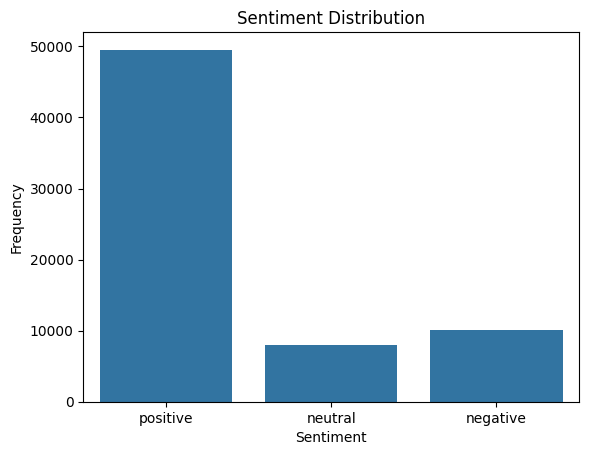

In [ ]:
sns.countplot(data=df1, x='Sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df1['reviewText']=df1['reviewText'].str.lower()
df1.head()

,reviewText,overall,Sentiment
0,they look good and stick good! i just don't li...,4.0,positive
1,these stickers work like the review says they ...,5.0,positive
2,these are awesome and make my phone look so st...,5.0,positive
3,item arrived in great time and was in perfect ...,4.0,positive
4,"awesome! stays on, and looks great. can be use...",5.0,positive


In [ ]:
df1['reviewText'] = df1['reviewText'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))) # Keep only letters and spaces
df1['reviewText'] = df1['reviewText'].apply(lambda x: re.sub(r'\s+', ' ', x).strip()) # Replace multiple spaces with single space and strip leading/trailing spaces

In [ ]:
def label(overall):
  if overall >=4:
    return "positive"
  elif overall == 3:
    return "neutral"
  else :
    return "negative"
df1['Sentiment'] = df1['overall'].apply(label)

In [ ]:
TfidfTransformer = TfidfVectorizer(stop_words=None)
X = TfidfTransformer.fit_transform(df1['reviewText'])
y = df1['Sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8060440372395449


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.72      0.59      0.65      2031
     neutral       0.45      0.15      0.22      1666
    positive       0.84      0.96      0.89      9837

    accuracy                           0.81     13534
   macro avg       0.67      0.57      0.59     13534
weighted avg       0.77      0.81      0.77     13534



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1207  114  710]
 [ 280  242 1144]
 [ 199  178 9460]]


In [ ]:
new_review = ["the product is good "]
new_review_tfidf = TfidfTransformer.transform(new_review)
prediction = model.predict(new_review_tfidf)
print(prediction)

['positive']
